Using device: cuda
Content image class: horse (index 7)
Images loaded.


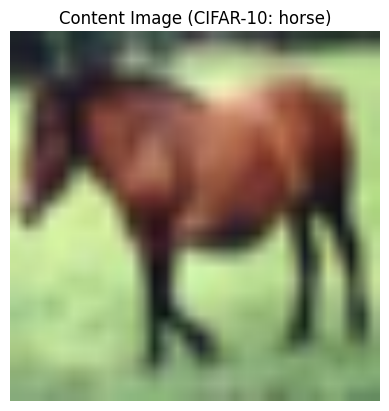

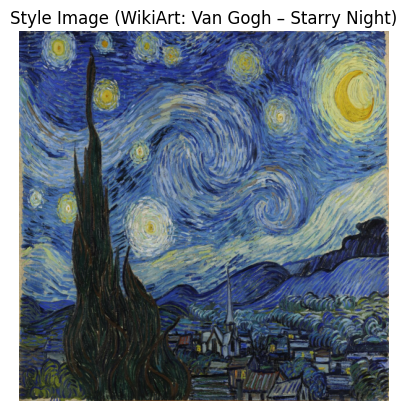

VGG19 loaded and frozen.
Starting optimisation for 800 steps on cuda ...
(~15-25 mins on GPU, ~45-60 mins on CPU)
  Step   50 | Total: 5.2265 | Content: 1.488140 | Style: 0.000004
  Step  100 | Total: 4.1257 | Content: 1.244134 | Style: 0.000003
  Step  150 | Total: 3.8884 | Content: 1.184004 | Style: 0.000003
  Step  200 | Total: 3.7478 | Content: 1.140428 | Style: 0.000002
  Step  250 | Total: 3.6485 | Content: 1.105988 | Style: 0.000002
  Step  300 | Total: 3.6540 | Content: 1.096507 | Style: 0.000002
  Step  350 | Total: 3.5276 | Content: 1.043175 | Style: 0.000002
  Step  400 | Total: 3.7770 | Content: 1.105448 | Style: 0.000003
  Step  450 | Total: 3.5767 | Content: 1.003525 | Style: 0.000002
  Step  500 | Total: 5.6876 | Content: 1.702543 | Style: 0.000006
  Step  550 | Total: 3.6949 | Content: 1.022237 | Style: 0.000002
  Step  600 | Total: 3.8708 | Content: 1.139671 | Style: 0.000002
  Step  650 | Total: 3.4855 | Content: 1.023797 | Style: 0.000002
  Step  700 | Total: 3.3643 

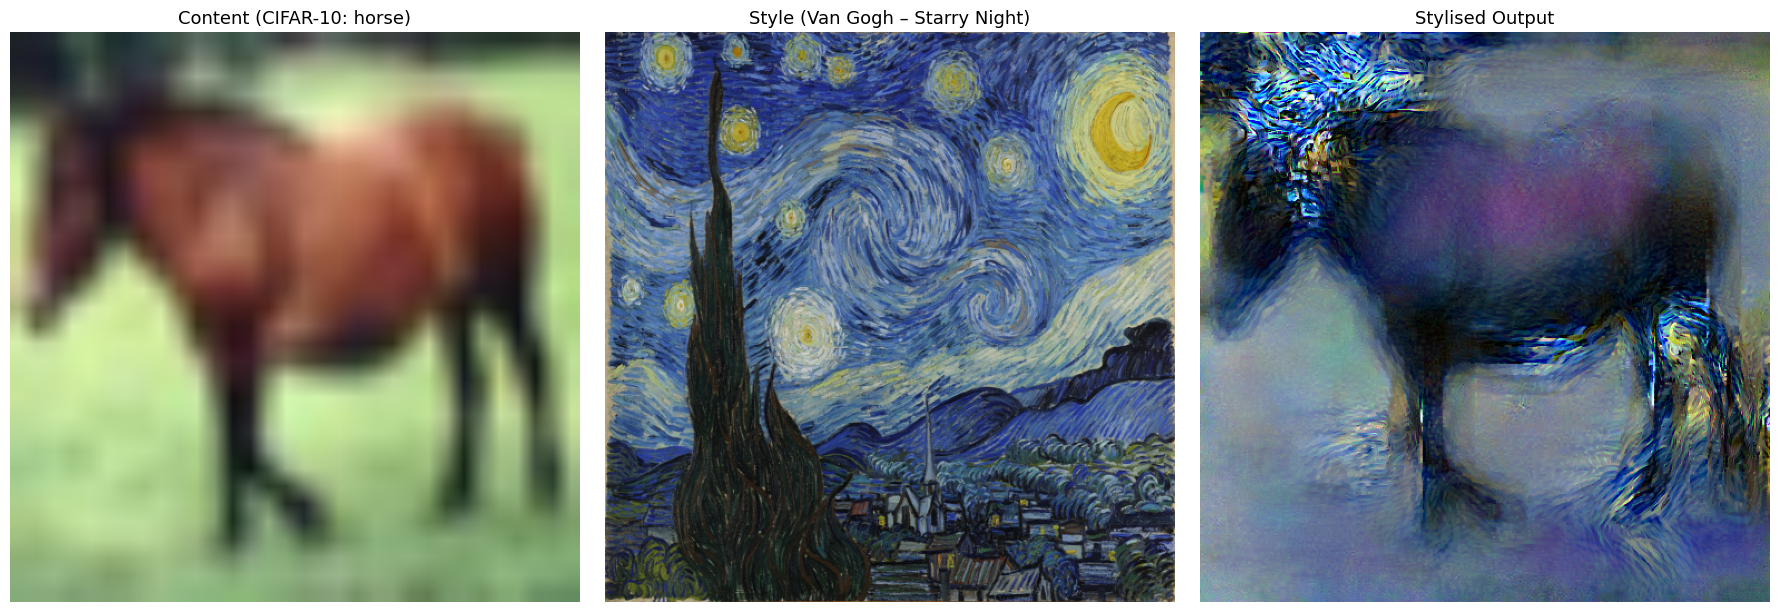

Done! Saved → nst_result.png


In [4]:
# ============================================================
#  CSET419 – Lab 7: Neural Style Transfer (NST)
#  Single cell – Colab ready
# ============================================================

# ---------- 0. Imports ----------
import torch, torch.nn as nn, torch.optim as optim
import torchvision.transforms as T
import torchvision.models as models
import torchvision.datasets as dsets
from PIL import Image
import matplotlib.pyplot as plt
import requests, io

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---------- 1. Image Helpers ----------
IMG_SIZE = 512  # ⬆ was 256 — higher res = better quality output

loader = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])

def load_image_from_url(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers, timeout=15)
    img = Image.open(io.BytesIO(response.content)).convert("RGB")
    return loader(img).unsqueeze(0).to(device)

def imshow(tensor, title=""):
    img = tensor.squeeze(0).cpu().clamp(0, 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(title); plt.axis("off"); plt.show()

# ---------- 2. Load Content Image from CIFAR-10 ----------
print("Downloading CIFAR-10 ...")
cifar = dsets.CIFAR10(root='./data', train=True, download=True)

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Pick a horse (index 7 in class list) — scan for first one
for idx in range(len(cifar)):
    raw_img, label = cifar[idx]
    if class_names[label] == "horse":
        break

content_img = loader(raw_img).unsqueeze(0).to(device)
print(f"Content image class: {class_names[label]} (index {idx})")

# ---------- 3. Load Style Image (Van Gogh – Starry Night) ----------
print("Downloading style image ...")
STYLE_URL = "https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/1280px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg"
style_img = load_image_from_url(STYLE_URL)

print("Images loaded.")
imshow(content_img, f"Content Image (CIFAR-10: {class_names[label]})")
imshow(style_img,   "Style Image (WikiArt: Van Gogh – Starry Night)")

# ---------- 4. Load Pretrained VGG19 (frozen) ----------
vgg = models.vgg19(pretrained=True).features.to(device).eval()
for p in vgg.parameters():
    p.requires_grad_(False)
print("VGG19 loaded and frozen.")

# ---------- 5. Normalization (ImageNet stats — improves VGG feature quality) ----------
norm_mean = torch.tensor([0.485, 0.456, 0.406]).to(device).view(1,3,1,1)
norm_std  = torch.tensor([0.229, 0.224, 0.225]).to(device).view(1,3,1,1)

def normalize(x):
    return (x - norm_mean) / norm_std

# ---------- 6. Feature Extractor ----------
CONTENT_LAYER = "21"
STYLE_LAYERS  = {"0": 1.0, "5": 0.8, "10": 0.5, "19": 0.3, "28": 0.2}

class FeatureExtractor(nn.Module):
    def __init__(self, model, style_layers, content_layer):
        super().__init__()
        self.model         = model
        self.style_layers  = style_layers
        self.content_layer = content_layer

    def forward(self, x):
        x = normalize(x)  # ✅ normalize before VGG
        style_feats, content_feat = {}, None
        for name, layer in self.model._modules.items():
            x = layer(x)
            if name in self.style_layers:
                style_feats[name] = x
            if name == self.content_layer:
                content_feat = x
        return content_feat, style_feats

extractor = FeatureExtractor(vgg, STYLE_LAYERS, CONTENT_LAYER)

# ---------- 7. Loss Functions ----------
def content_loss(gen_feat, content_feat):
    return nn.functional.mse_loss(gen_feat, content_feat)

def gram_matrix(feat):
    b, c, h, w = feat.size()
    f = feat.view(b * c, h * w)
    return torch.mm(f, f.t()) / (b * c * h * w)

def style_loss(gen_feats, style_feats, weights):
    loss = 0
    for layer, w in weights.items():
        G = gram_matrix(gen_feats[layer])
        A = gram_matrix(style_feats[layer])
        loss += w * nn.functional.mse_loss(G, A)
    return loss

def total_variation_loss(img):
    return (torch.sum(torch.abs(img[:, :, :, :-1] - img[:, :, :, 1:])) +
            torch.sum(torch.abs(img[:, :, :-1, :] - img[:, :, 1:, :])))

# ---------- 8. Pre-compute Target Features ----------
with torch.no_grad():
    content_target, _  = extractor(content_img)
    _, style_target    = extractor(style_img)

# ---------- 9. Optimisation ----------
gen_img = content_img.clone().requires_grad_(True)

ALPHA  = 1.0      # content weight
BETA   = 3e5      # ⬆ stronger style
TV_W   = 5e-5     # slightly less smoothing → sharper details
STEPS  = 800      # ⬆ was 400 — more steps = better convergence

# ⬆ max_iter=40 — L-BFGS does more work per outer step
optimizer = optim.LBFGS([gen_img], lr=1.0, max_iter=40)

print(f"Starting optimisation for {STEPS} steps on {device} ...")
print("(~15-25 mins on GPU, ~45-60 mins on CPU)")
step_counter = [0]

def closure():
    gen_img.data.clamp_(0, 1)
    optimizer.zero_grad()

    gen_content, gen_style = extractor(gen_img)

    c_loss  = content_loss(gen_content, content_target)
    s_loss  = style_loss(gen_style, style_target, STYLE_LAYERS)
    tv_loss = total_variation_loss(gen_img)
    total   = ALPHA * c_loss + BETA * s_loss + TV_W * tv_loss

    total.backward()

    step_counter[0] += 1
    if step_counter[0] % 50 == 0:
        print(f"  Step {step_counter[0]:4d} | "
              f"Total: {total.item():.4f} | "
              f"Content: {c_loss.item():.6f} | "
              f"Style: {s_loss.item():.6f}")
    return total

for _ in range(STEPS // 40):
    optimizer.step(closure)

gen_img.data.clamp_(0, 1)

# ---------- 10. Display Results ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, img, title in zip(axes,
                           [content_img, style_img, gen_img],
                           [f"Content (CIFAR-10: {class_names[label]})",
                            "Style (Van Gogh – Starry Night)",
                            "Stylised Output"]):
    ax.imshow(img.squeeze(0).cpu().detach().clamp(0, 1).permute(1, 2, 0))
    ax.set_title(title, fontsize=13)
    ax.axis("off")

plt.tight_layout()
plt.savefig("nst_result.png", dpi=150, bbox_inches="tight")
plt.show()
print("Done! Saved → nst_result.png")